## 数据预处理

In [1]:
import torch
from PIL import Image
import torchvision.transforms as T
import os
from torch.utils.data import Dataset, random_split, DataLoader

In [3]:
# 自定义数据集类
class NoisyImageDataset(Dataset):
    # 初始化：传入图片根目录，以及预处理转换操作
    def __init__(self, main_dir, transform=None):
        self.main_dir = main_dir
        self.transform = transform
        self.img_names = os.listdir(main_dir)

    # 获取数据集大小
    def __len__(self):
        return len(self.img_names)

    # 根据索引号得到（input, target）
    def __getitem__(self, idx):
        # 1. 根据索引号找到文件名，读取图片数据
        img_path = os.path.join(self.main_dir, self.img_names[idx])
        img = Image.open(img_path).convert('RGB')
        # 2. 将原始图片转换为符合模型输入要求的张量,这就是重构图像的目标
        if self.transform is not None:
            img_original_tensor = self.transform(img)
        else:
            raise ValueError("Transform must be provided!")
        # 3. 添加随机噪声（高斯噪声），构建输入数据
        noise_factor = 0.5
        img_noise_tensor = img_original_tensor + torch.randn_like(img_original_tensor) * noise_factor
        img_noise_tensor = img_noise_tensor.clamp(0., 1.)
        # 将输入和目标返回
        return img_noise_tensor, img_original_tensor

In [4]:
# 定义转换操作
transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
])

In [5]:
dataset = NoisyImageDataset(main_dir='../common/dataset', transform=transform)
print(len(dataset))

24853


In [5]:
print(dataset[0])
print(dataset[1][0].shape)

(tensor([[[1.0000, 0.8363, 1.0000,  ..., 0.8463, 0.7725, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 0.9324],
         [0.6028, 0.9998, 1.0000,  ..., 1.0000, 0.9191, 1.0000],
         ...,
         [0.5831, 1.0000, 0.7065,  ..., 1.0000, 0.7865, 1.0000],
         [1.0000, 0.7645, 0.6707,  ..., 0.7404, 1.0000, 0.9343],
         [1.0000, 0.2684, 1.0000,  ..., 1.0000, 1.0000, 1.0000]],

        [[1.0000, 1.0000, 1.0000,  ..., 1.0000, 0.0583, 1.0000],
         [0.5123, 1.0000, 0.0000,  ..., 1.0000, 1.0000, 0.8464],
         [1.0000, 0.9052, 0.8914,  ..., 0.3442, 1.0000, 0.4884],
         ...,
         [0.4868, 0.6375, 0.3124,  ..., 0.2303, 0.5723, 1.0000],
         [0.0701, 1.0000, 1.0000,  ..., 0.6032, 1.0000, 0.3240],
         [1.0000, 1.0000, 1.0000,  ..., 0.9678, 1.0000, 1.0000]],

        [[0.6273, 1.0000, 1.0000,  ..., 0.7645, 0.4887, 0.8112],
         [1.0000, 0.8864, 0.1459,  ..., 1.0000, 1.0000, 0.1646],
         [0.7641, 0.6351, 1.0000,  ..., 1.0000, 1.0000, 0

In [6]:
# 划分数据集
train_dataset, test_dataset = random_split(dataset, [0.75, 0.25])
print(len(train_dataset))
print(len(test_dataset))

18640
6213


In [7]:
# 构建数据加载器
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, drop_last=True)

In [17]:
data_iter = iter(train_loader)

In [18]:
input, target = next(data_iter)
print(input.shape)
print(target.shape)

torch.Size([32, 3, 64, 64])
torch.Size([32, 3, 64, 64])


## 定义模型

In [8]:
import torch.nn as nn
# 自定义自编码器模型
class ConvDenoiser(nn.Module):
    def __init__(self):
        super(ConvDenoiser, self).__init__()
        # 编码器部分
        # 卷积层
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 16, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        # 池化层(通用)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # 解码器部分
        # 转置卷积层
        self.conv_t1 = nn.ConvTranspose2d(8, 8, kernel_size=2, stride=2)
        self.conv_t2 = nn.ConvTranspose2d(8, 16, kernel_size=2, stride=2)
        self.conv_t3 = nn.ConvTranspose2d(16, 32, kernel_size=2, stride=2)
        # 输出前普通卷积
        self.conv_out = nn.Conv2d(32, 3, kernel_size=3, padding=1)

    # 前向传播
    def forward(self, x):
        # 第一层卷积-池化
        x = torch.relu(self.conv1(x))
        # print("conv1 shape: ", x.shape)
        x = self.pool(x)
        # print("pool1 shape: ", x.shape)
        # 第二层卷积-池化
        x = torch.relu(self.conv2(x))
        # print("conv2 shape: ", x.shape)
        x = self.pool(x)
        # print("pool2 shape: ", x.shape)
        # 第三层卷积-池化
        x = torch.relu(self.conv3(x))
        # print("conv3 shape: ", x.shape)
        x = self.pool(x)
        # print("pool3 shape: ", x.shape)
        # print("Encoder output shape: ", x.shape)
        # 解码
        x = torch.relu(self.conv_t1(x))
        # print("conv1 t1 shape: ", x.shape)
        x = torch.relu(self.conv_t2(x))
        # print("conv2 t2 shape: ", x.shape)
        x = torch.relu(self.conv_t3(x))
        # print("conv3 t3 shape: ", x.shape)
        # 最后普通卷积
        x = torch.sigmoid(self.conv_out(x))
        return x

In [9]:
model = ConvDenoiser()
print(model)

ConvDenoiser(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_t1): ConvTranspose2d(8, 8, kernel_size=(2, 2), stride=(2, 2))
  (conv_t2): ConvTranspose2d(8, 16, kernel_size=(2, 2), stride=(2, 2))
  (conv_t3): ConvTranspose2d(16, 32, kernel_size=(2, 2), stride=(2, 2))
  (conv_out): Conv2d(32, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)


In [25]:
output = model(input)
print(output.shape)

torch.Size([32, 3, 64, 64])


## 模型训练

In [10]:
# 1. 定义设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

ConvDenoiser(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_t1): ConvTranspose2d(8, 8, kernel_size=(2, 2), stride=(2, 2))
  (conv_t2): ConvTranspose2d(8, 16, kernel_size=(2, 2), stride=(2, 2))
  (conv_t3): ConvTranspose2d(16, 32, kernel_size=(2, 2), stride=(2, 2))
  (conv_out): Conv2d(32, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)

In [11]:
# 2. 定义超参数
lr = 0.001
epochs = 10

In [12]:
import torch.optim as optim
# 3. 定义损失函数和优化器
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

In [13]:
# 4. 训练流程
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for input, target in train_loader:
        input = input.to(device)
        target = target.to(device)
        # 前向传播
        output = model(input)
        # 计算损失
        loss = loss_fn(output, target)
        # 反向传播
        loss.backward()
        # 更新参数
        optimizer.step()
        # 梯度清零
        optimizer.zero_grad()
        # 累加损失
        train_loss += loss.item()
    # 计算本轮平均损失
    this_train_loss = train_loss / len(train_loader)
    print(f"Epoch {epoch + 1}, train loss: {this_train_loss}")

Epoch 1, train loss: 0.037498107487239786
Epoch 2, train loss: 0.012337666955421265
Epoch 3, train loss: 0.011500642898962977
Epoch 4, train loss: 0.011099942817426323
Epoch 5, train loss: 0.010863545624366434
Epoch 6, train loss: 0.01068841244247694
Epoch 7, train loss: 0.010540324226469826
Epoch 8, train loss: 0.010387631525250338
Epoch 9, train loss: 0.01027623641535102
Epoch 10, train loss: 0.010173481760252127


## 测试

In [15]:
# 1. 选取一批测试数据
test_iter = iter(test_loader)
noisy_images, images = next(test_iter)
print(noisy_images.shape)
print(images.shape)

torch.Size([32, 3, 64, 64])
torch.Size([32, 3, 64, 64])


In [16]:
# 2. 推理预测
with torch.no_grad():
    noisy_images = noisy_images.to(device)
    # 前向传播
    outputs = model(noisy_images)
print(outputs.shape)

torch.Size([32, 3, 64, 64])


In [17]:
# 3. 数据转换，为画图做准备
noisy_images = noisy_images.permute(0, 2, 3, 1).cpu().numpy()
print(noisy_images.shape)

(32, 64, 64, 3)


In [18]:
outputs = outputs.permute(0, 2, 3, 1).cpu().numpy()
images = images.permute(0, 2, 3, 1).cpu().numpy()

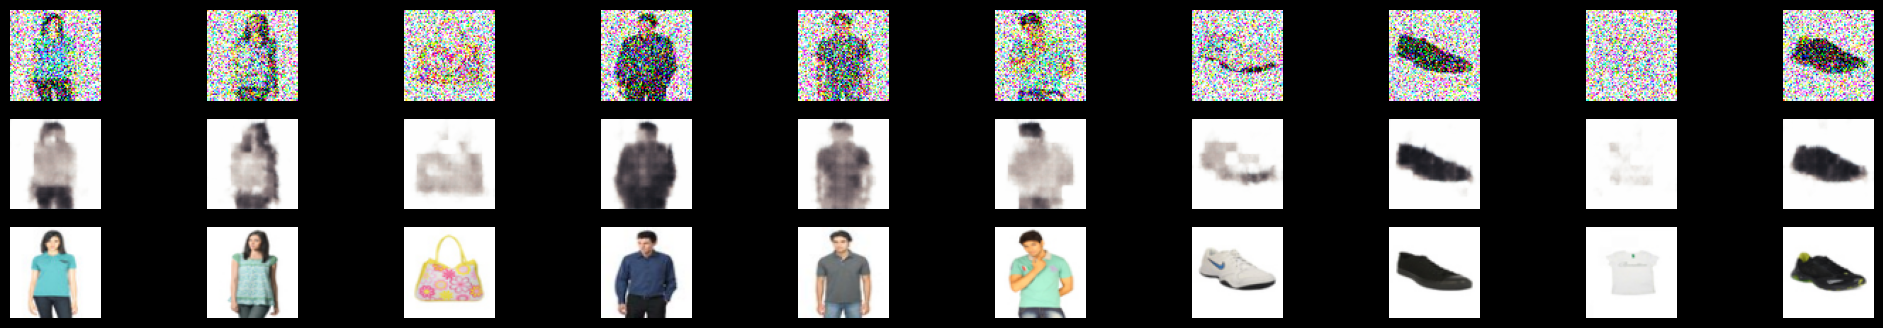

In [20]:
import matplotlib.pyplot as plt
# 4. 画图
fig, axes = plt.subplots(nrows=3, ncols=10, figsize=(25, 4), sharex=True, sharey=True)
for imgs, ax_row in zip([noisy_images, outputs, images], axes):
    for img, ax in zip(imgs, ax_row):
        ax.imshow(img)
        ax.set_axis_off()
plt.show()

In [7]:
print(dataset.img_names)

['0.jpg', '1.jpg', '10.jpg', '100.jpg', '1000.jpg', '10000.jpg', '10001.jpg', '10002.jpg', '10003.jpg', '10004.jpg', '10005.jpg', '10006.jpg', '10007.jpg', '10008.jpg', '10009.jpg', '1001.jpg', '10010.jpg', '10011.jpg', '10012.jpg', '10013.jpg', '10014.jpg', '10015.jpg', '10016.jpg', '10017.jpg', '10018.jpg', '10019.jpg', '1002.jpg', '10020.jpg', '10021.jpg', '10022.jpg', '10023.jpg', '10024.jpg', '10025.jpg', '10026.jpg', '10027.jpg', '10028.jpg', '10029.jpg', '1003.jpg', '10030.jpg', '10031.jpg', '10032.jpg', '10033.jpg', '10034.jpg', '10035.jpg', '10036.jpg', '10037.jpg', '10038.jpg', '10039.jpg', '1004.jpg', '10040.jpg', '10041.jpg', '10042.jpg', '10043.jpg', '10044.jpg', '10045.jpg', '10046.jpg', '10047.jpg', '10048.jpg', '10049.jpg', '1005.jpg', '10050.jpg', '10051.jpg', '10052.jpg', '10053.jpg', '10054.jpg', '10055.jpg', '10056.jpg', '10057.jpg', '10058.jpg', '10059.jpg', '1006.jpg', '10060.jpg', '10061.jpg', '10062.jpg', '10063.jpg', '10064.jpg', '10065.jpg', '10066.jpg', '1006

In [8]:
img_name1 = "class01img100.jpg"
img_name2 = "class01img2.jpg"
print(img_name1 > img_name2)

False


In [11]:
import re
img1 = re.split(r'([0-9]+)', img_name1)
img2 = re.split(r'([0-9]+)', img_name2)
print(img1)
print(img2)

['class', '01', 'img', '100', '.jpg']
['class', '01', 'img', '2', '.jpg']


In [13]:
print(img1 > img2)

False


In [17]:
# 定义一个转换函数：字符转成小写，如果是数字提取数值
convert = lambda str: int(str) if str.isdigit() else str.lower()

In [18]:
img1 = [ convert(x) for x in img1 ]
img2 = [ convert(x) for x in img2 ]
print(img1)
print(img2)

['class', 1, 'img', 100, '.jpg']
['class', 1, 'img', 2, '.jpg']


In [19]:
print(img1 > img2)

True


In [20]:
imgs = dataset.img_names
print(imgs)

['0.jpg', '1.jpg', '10.jpg', '100.jpg', '1000.jpg', '10000.jpg', '10001.jpg', '10002.jpg', '10003.jpg', '10004.jpg', '10005.jpg', '10006.jpg', '10007.jpg', '10008.jpg', '10009.jpg', '1001.jpg', '10010.jpg', '10011.jpg', '10012.jpg', '10013.jpg', '10014.jpg', '10015.jpg', '10016.jpg', '10017.jpg', '10018.jpg', '10019.jpg', '1002.jpg', '10020.jpg', '10021.jpg', '10022.jpg', '10023.jpg', '10024.jpg', '10025.jpg', '10026.jpg', '10027.jpg', '10028.jpg', '10029.jpg', '1003.jpg', '10030.jpg', '10031.jpg', '10032.jpg', '10033.jpg', '10034.jpg', '10035.jpg', '10036.jpg', '10037.jpg', '10038.jpg', '10039.jpg', '1004.jpg', '10040.jpg', '10041.jpg', '10042.jpg', '10043.jpg', '10044.jpg', '10045.jpg', '10046.jpg', '10047.jpg', '10048.jpg', '10049.jpg', '1005.jpg', '10050.jpg', '10051.jpg', '10052.jpg', '10053.jpg', '10054.jpg', '10055.jpg', '10056.jpg', '10057.jpg', '10058.jpg', '10059.jpg', '1006.jpg', '10060.jpg', '10061.jpg', '10062.jpg', '10063.jpg', '10064.jpg', '10065.jpg', '10066.jpg', '1006

In [21]:
print(sorted(imgs, key=lambda str: str.lower()))

['0.jpg', '1.jpg', '10.jpg', '100.jpg', '1000.jpg', '10000.jpg', '10001.jpg', '10002.jpg', '10003.jpg', '10004.jpg', '10005.jpg', '10006.jpg', '10007.jpg', '10008.jpg', '10009.jpg', '1001.jpg', '10010.jpg', '10011.jpg', '10012.jpg', '10013.jpg', '10014.jpg', '10015.jpg', '10016.jpg', '10017.jpg', '10018.jpg', '10019.jpg', '1002.jpg', '10020.jpg', '10021.jpg', '10022.jpg', '10023.jpg', '10024.jpg', '10025.jpg', '10026.jpg', '10027.jpg', '10028.jpg', '10029.jpg', '1003.jpg', '10030.jpg', '10031.jpg', '10032.jpg', '10033.jpg', '10034.jpg', '10035.jpg', '10036.jpg', '10037.jpg', '10038.jpg', '10039.jpg', '1004.jpg', '10040.jpg', '10041.jpg', '10042.jpg', '10043.jpg', '10044.jpg', '10045.jpg', '10046.jpg', '10047.jpg', '10048.jpg', '10049.jpg', '1005.jpg', '10050.jpg', '10051.jpg', '10052.jpg', '10053.jpg', '10054.jpg', '10055.jpg', '10056.jpg', '10057.jpg', '10058.jpg', '10059.jpg', '1006.jpg', '10060.jpg', '10061.jpg', '10062.jpg', '10063.jpg', '10064.jpg', '10065.jpg', '10066.jpg', '1006

In [22]:
# 定义一个排序key函数，按字母-数字切分，得到列表作为key
alphanum = lambda str: [ convert(x) for x in re.split('([0-9]+)', str) ]

In [23]:
print( sorted( imgs, key=alphanum) )

['0.jpg', '1.jpg', '2.jpg', '3.jpg', '4.jpg', '5.jpg', '6.jpg', '7.jpg', '8.jpg', '9.jpg', '10.jpg', '11.jpg', '12.jpg', '13.jpg', '14.jpg', '15.jpg', '16.jpg', '17.jpg', '18.jpg', '19.jpg', '20.jpg', '21.jpg', '22.jpg', '23.jpg', '24.jpg', '25.jpg', '26.jpg', '27.jpg', '28.jpg', '29.jpg', '30.jpg', '31.jpg', '32.jpg', '33.jpg', '34.jpg', '35.jpg', '36.jpg', '37.jpg', '38.jpg', '39.jpg', '40.jpg', '41.jpg', '42.jpg', '43.jpg', '44.jpg', '45.jpg', '46.jpg', '47.jpg', '48.jpg', '49.jpg', '50.jpg', '51.jpg', '52.jpg', '53.jpg', '54.jpg', '55.jpg', '56.jpg', '57.jpg', '58.jpg', '59.jpg', '60.jpg', '61.jpg', '62.jpg', '63.jpg', '64.jpg', '65.jpg', '66.jpg', '67.jpg', '68.jpg', '69.jpg', '70.jpg', '71.jpg', '72.jpg', '73.jpg', '74.jpg', '75.jpg', '76.jpg', '77.jpg', '78.jpg', '79.jpg', '80.jpg', '81.jpg', '82.jpg', '83.jpg', '84.jpg', '85.jpg', '86.jpg', '87.jpg', '88.jpg', '89.jpg', '90.jpg', '91.jpg', '92.jpg', '93.jpg', '94.jpg', '95.jpg', '96.jpg', '97.jpg', '98.jpg', '99.jpg', '100.jpg'